In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from bjontegaard import bd_rate, bd_psnr

Load Quantized Dataframe

In [2]:

# rótulos, na ordem informada
COLS_QUANTIZED = ['a', 'w', 'calib_res', 'calib_seq', 'frames',
           'dataset', 'quality', 'seq', 'bpp', 'psnr']


RESULTS_QUANTIZED_PATH = "ZRESULTS.txt"

df = pd.read_csv(
    RESULTS_QUANTIZED_PATH,
    header=None,
    names=COLS_QUANTIZED,
    sep=",",
    skipinitialspace=True,   # ignora espaços após vírgulas
    engine="python"          # robusto a pequenas variações
)

    # conversão de tipos (opcional, mas útil)
for c in ['a', 'w', 'calib_res', 'calib_seq', 'frames', 'quality']:
    df[c] = pd.to_numeric(df[c], errors='coerce', downcast='integer')
for c in ['bpp', 'psnr']:
    df[c] = pd.to_numeric(df[c], errors='coerce')

df_quant_allq = df
df_quant = df[df['quality'] % 2 != 0]

Load Anchor Dataframe

In [3]:
COLS_ANCHOR = ['frames', 'dataset', 'quality', 'seq', 'bpp', 'psnr']

RESULTS_ANCHOR_PATH = "ZRESULTS_ANCHOR.txt"

df = pd.read_csv(
    RESULTS_ANCHOR_PATH,
    header=None,
    names=COLS_ANCHOR,
    sep=",",
    skipinitialspace=True,   # ignora espaços após vírgulas
    engine="python"          # robusto a pequenas variações
)

    # conversão de tipos (opcional, mas útil)
for c in ['frames', 'quality']:
    df[c] = pd.to_numeric(df[c], errors='coerce', downcast='integer')
for c in ['bpp', 'psnr']:
    df[c] = pd.to_numeric(df[c], errors='coerce')


df_anchor_allq = df
df_anchor = df[df['quality'] % 2 != 0]

In [4]:
print("QUANTIZED:\n",df_quant.head())

print("\n\nANCHOR:\n",df_anchor.head())

QUANTIZED:
    a  w  calib_res  calib_seq  frames dataset  quality            seq  \
0  4  4        256       1000      32     UVG        1         Beauty   
1  4  4        256       1000      32     UVG        1      Bosphorus   
2  4  4        256       1000      32     UVG        1       HoneyBee   
3  4  4        256       1000      32     UVG        1         Jockey   
4  4  4        256       1000      32     UVG        1  ReadySteadyGo   

        bpp     psnr  
0  0.027270  34.5242  
1  0.048316  33.8013  
2  0.045217  32.6916  
3  0.067802  33.5875  
4  0.111744  30.6790  


ANCHOR:
    frames dataset  quality            seq       bpp     psnr
0      32     UVG        1         Beauty  0.012949  35.1549
1      32     UVG        1      Bosphorus  0.022664  34.5400
2      32     UVG        1       HoneyBee  0.017290  33.8813
3      32     UVG        1         Jockey  0.036744  34.2024
4      32     UVG        1  ReadySteadyGo  0.054470  31.3666


In [5]:

import pandas as pd
import numpy as np

def averages_by_quality(df, w=None, a=None, calib_res=None, calib_seq=None, frames=None, dataset=None):
    """
    Filters the DataFrame and returns three NumPy arrays:
      - quality_vals : quality values (sorted)
      - bpp_means    : average bpp for each quality
      - psnr_means   : average psnr for each quality

    Any parameter can be set to None to skip filtering by that field.
    """
    cond = pd.Series(True, index=df.index)

    if w is not None:
        cond &= (df['w'] == w)
    if a is not None:
        cond &= (df['a'] == a)
    if calib_res is not None:
        cond &= (df['calib_res'] == calib_res)
    if calib_seq is not None:
        cond &= (df['calib_seq'] == calib_seq)
    if frames is not None:
        cond &= (df['frames'] == frames)
    if dataset is not None:
        cond &= (df['dataset'] == dataset)

    df_filtered = df[cond]

    if df_filtered.empty:
        raise ValueError("No data found with these parameters.")

    df_group = df_filtered.groupby('quality').agg(
        bpp_mean=('bpp', 'mean'),
        psnr_mean=('psnr', 'mean')
    ).reset_index().sort_values('quality')

    quality_vals = df_group['quality'].to_numpy()
    bpp_means = df_group['bpp_mean'].to_numpy()
    psnr_means = df_group['psnr_mean'].to_numpy()

    return quality_vals, bpp_means, psnr_means


# === Exemplo de uso ===
# q1, bpp1, psnr1 = averages_by_quality(
#     df_quant,
#     w=8, a=12,
#     calib_res=256, calib_seq=1000, frames=32,
#     dataset=None
# )

# # 2) Considerando todos os datasets
# q2, bpp2, psnr2 = averages_by_quality(
#     df_anchor,
#     frames=32,
#     dataset=None
# )


In [6]:
# df_quant = df_quant[df_quant['frames'] == 32]
# df_anchor = df_anchor[df_anchor['frames'] == 32]

In [7]:
import pandas as pd

resultados = []

datasets_list = list(df_anchor['dataset'].unique()) + [None]

for dataset in datasets_list:
    for f in df_anchor['frames'].unique():
        
        q, bpp_anchor, psnr_anchor = averages_by_quality(
            df_anchor,
            frames=f,
            dataset=dataset
        )

        for w in [4, 8, 12, 16]:
            for a in [4, 8, 12, 16]:
                try:
                    q, bpp, psnr = averages_by_quality(
                        df_quant,
                        w=w, a=a,
                        calib_res=256, calib_seq=1000, frames=f,
                        dataset=dataset
                    )

                    bd_rate_val = bd_rate(bpp_anchor, psnr_anchor, bpp, psnr, 'akima')

                    resultados.append({
                        "a": a,
                        "w": w,
                        "dataset": "Average" if dataset is None else dataset,
                        "frames": f,
                        "bd_rate": bd_rate_val
                    })
                except ValueError as e:
                    print(f"w={w}, a={a}, dataset={dataset}, frames={f}: {e}")
                    continue

df_bd_rate = pd.DataFrame(resultados)


In [8]:
DATASET = 'HEVC-B' 
FRAMES = 96

df_show = df_bd_rate[(df_bd_rate['dataset']  == DATASET) & (df_bd_rate['frames']  == FRAMES)]
df_show = df_show[["w", "a", 'bd_rate']].reset_index(drop=True).sort_values(by=['w', 'a'])
# display(df_show.style.hide(axis="index"))
df_show
# list_show = [round(x,1) for x in  df_show['bd_rate'].to_list()]
# list_show

,w,a,bd_rate
0,4,4,246.122514
1,4,8,84.649169
2,4,12,79.312659
3,4,16,79.232072
4,8,4,203.698960
5,8,8,5.947489
6,8,12,2.394878
7,8,16,2.316043
8,12,4,199.464020
9,12,8,3.056960


BD-Rate (W=4, A=4): 266.91%
BD-Rate (W=4, A=8): 100.95%
BD-Rate (W=4, A=12): 95.00%
BD-Rate (W=4, A=16): 95.12%
BD-Rate (W=8, A=4): 215.77%
BD-Rate (W=8, A=8): 6.48%
BD-Rate (W=8, A=12): 1.89%
BD-Rate (W=8, A=16): 2.00%
BD-Rate (W=12, A=4): 210.37%
BD-Rate (W=12, A=8): 4.03%
BD-Rate (W=12, A=12): 0.04%
BD-Rate (W=12, A=16): -0.16%
BD-Rate (W=16, A=4): 211.10%
BD-Rate (W=16, A=8): 4.03%
BD-Rate (W=16, A=12): -0.01%
BD-Rate (W=16, A=16): -0.01%


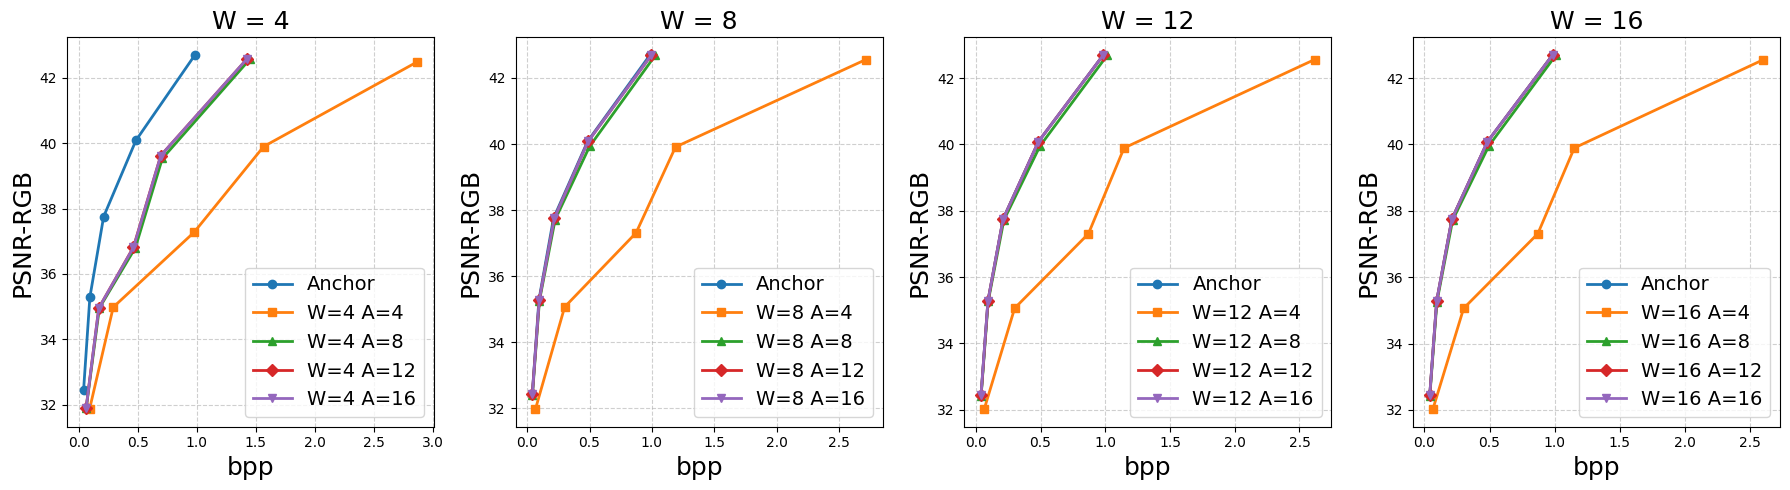

In [9]:
import matplotlib.pyplot as plt
import random

colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red',
         'tab:pink',]
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'P', 'X']
linestyles = ['-', '--', '-.', ':']


plt.figure(figsize=(18, 5))
q, bpp_anchor, psnr_anchor = averages_by_quality(df_anchor, frames=32, dataset=None)

# for w in [4]:
for i, w in enumerate([4, 8, 12, 16]):
    plt.subplot(1, 4, i+1)
    
    plt.plot(
                bpp_anchor, psnr_anchor,
                label=f'Anchor',    
                linewidth=2,
                marker=markers[0]            
            )
    
    for j,a in enumerate([4, 8, 12, 16]):            
        q, bpp, psnr = averages_by_quality(
            df_quant,
            w=w, a=a,
            calib_res=256, calib_seq=1000, frames=32,
            dataset=None
        )
        
        color = random.choice(colors)
        marker = random.choice(markers)
        ls = random.choice(linestyles)       
        
        
        plt.plot(
            bpp, psnr,
            label=f'W={w} A={a}', 
            linewidth=2,
            marker=markers[j+1]           
        )

        bd_rate_val = bd_rate(bpp_anchor, psnr_anchor, bpp, psnr, 'akima')
        print(f'BD-Rate (W={w}, A={a}): {bd_rate_val:.2f}%')
        plt.title(f"W = {w}", fontsize=18)
        plt.xlabel('bpp', fontsize=18)
        plt.ylabel('PSNR-RGB', fontsize=18)        
        plt.legend(fontsize=14)
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()    
        

plt.show()


Figure to justify only odd points

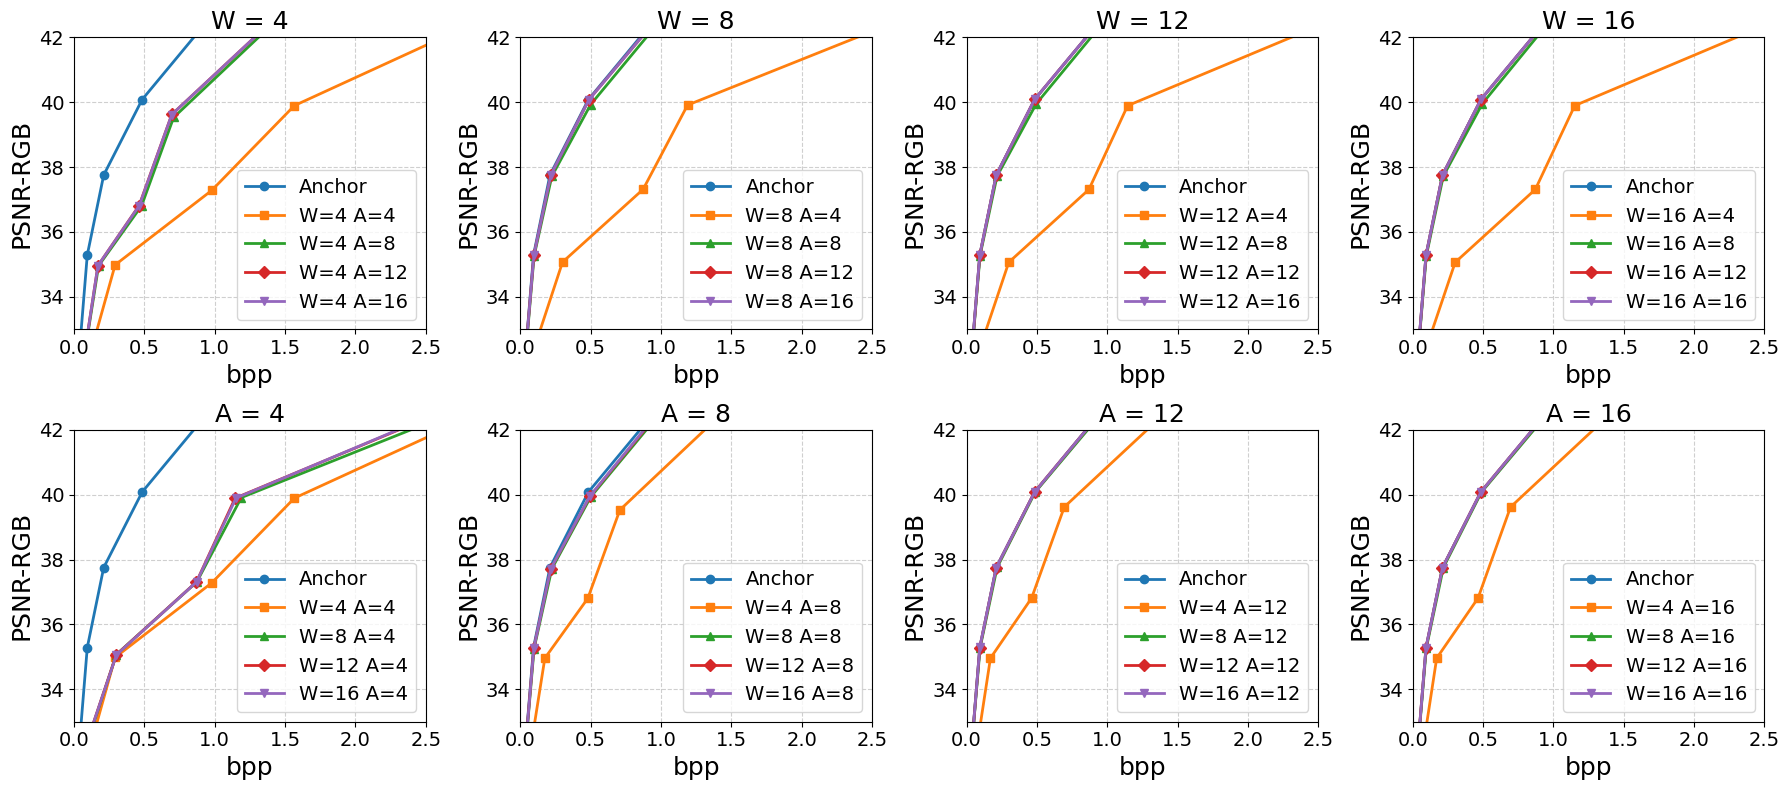

In [10]:
plt.figure(figsize=(18, 8))
q, bpp_anchor, psnr_anchor = averages_by_quality(df_anchor, frames=32, dataset=None)


# for w in [4]:
for i, w in enumerate([4, 8, 12, 16]):
    plt.subplot(2, 4, i+1)
    
    plt.plot(
                bpp_anchor, psnr_anchor,
                label=f'Anchor',    
                linewidth=2,
                marker=markers[0]            
            )
    
    for j,a in enumerate([4, 8, 12, 16]):            
        q, bpp, psnr = averages_by_quality(
            df_quant,
            w=w, a=a,
            calib_res=256, calib_seq=1000, frames=32,
            dataset=None
        )
        
        plt.plot(
            bpp, psnr,
            label=f'W={w} A={a}', 
            linewidth=2,
            marker=markers[j+1]           
        )
    plt.title(f"W = {w}", fontsize=18)
    plt.xlabel('bpp', fontsize=18)
    plt.ylabel('PSNR-RGB', fontsize=18)  
    plt.tick_params(axis='both', labelsize=14)  # aumenta os ticks dos eixos
    plt.xlim(0, 2.5)    # eixo X vai de 0 a 1.0
    plt.ylim(33, 42)    # eixo Y vai de 20 a 50
    plt.legend(fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()    
        

for i, a in enumerate([4, 8, 12, 16]):
    plt.subplot(2, 4, i+1+4)
    
    plt.plot(
                bpp_anchor, psnr_anchor,
                label=f'Anchor',    
                linewidth=2,
                marker=markers[0]            
            )
    
    for j,w in enumerate([4, 8, 12, 16]):            
        q, bpp, psnr = averages_by_quality(
            df_quant,
            w=w, a=a,
            calib_res=256, calib_seq=1000, frames=32,
            dataset=None
        )
        
        color = random.choice(colors)
        marker = random.choice(markers)
        ls = random.choice(linestyles)       
        
        
        plt.plot(
            bpp, psnr,
            label=f'W={w} A={a}', 
            linewidth=2,
            marker=markers[j+1]           
        )

    plt.title(f"A = {a}", fontsize=18)
    plt.xlabel('bpp', fontsize=18)
    plt.ylabel('PSNR-RGB', fontsize=18)        
    plt.tick_params(axis='both', labelsize=14)  # aumenta os ticks dos eixos
    plt.xlim(0, 2.5)    # eixo X vai de 0 a 1.0
    plt.ylim(33, 42)    # eixo Y vai de 20 a 50

    plt.legend(fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()  


plt.savefig("analysis_comparison_output.pdf", dpi=600, bbox_inches="tight")   # formato PNG

plt.show()



BD-Rate (W=4, A=4): 266.91%
BD-Rate (W=8, A=4): 215.77%
BD-Rate (W=12, A=4): 210.37%
BD-Rate (W=16, A=4): 211.10%
BD-Rate (W=4, A=8): 100.95%
BD-Rate (W=8, A=8): 6.48%
BD-Rate (W=12, A=8): 4.03%
BD-Rate (W=16, A=8): 4.03%
BD-Rate (W=4, A=12): 95.00%
BD-Rate (W=8, A=12): 1.89%
BD-Rate (W=12, A=12): 0.04%
BD-Rate (W=16, A=12): -0.01%
BD-Rate (W=4, A=16): 95.12%
BD-Rate (W=8, A=16): 2.00%
BD-Rate (W=12, A=16): -0.16%
BD-Rate (W=16, A=16): -0.01%


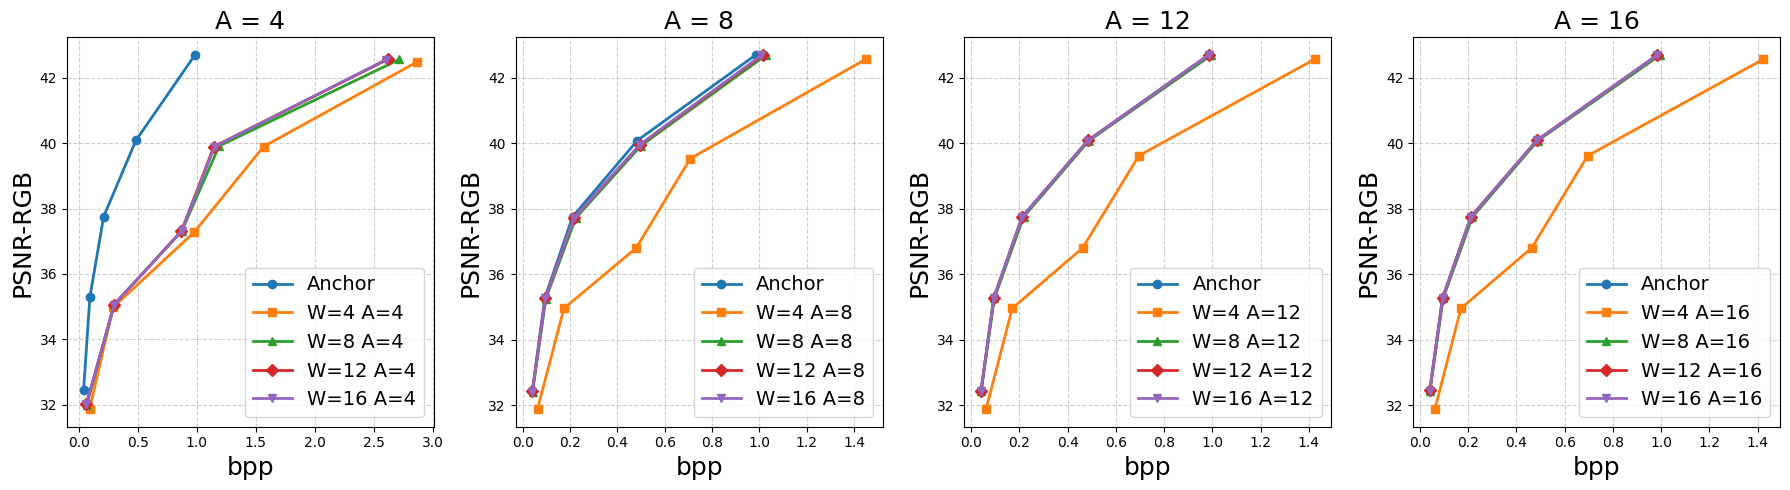

In [11]:
import matplotlib.pyplot as plt
import random

colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red',
         'tab:pink',]
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'P', 'X']
linestyles = ['-', '--', '-.', ':']


plt.figure(figsize=(18, 5))
q, bpp_anchor, psnr_anchor = averages_by_quality(df_anchor, frames=32, dataset=None)

# for w in [4]:
for i, a in enumerate([4, 8, 12, 16]):
    plt.subplot(1, 4, i+1)
    
    plt.plot(
                bpp_anchor, psnr_anchor,
                label=f'Anchor',    
                linewidth=2,
                marker=markers[0]            
            )
    
    for j,w in enumerate([4, 8, 12, 16]):            
        q, bpp, psnr = averages_by_quality(
            df_quant,
            w=w, a=a,
            calib_res=256, calib_seq=1000, frames=32,
            dataset=None
        )
        
        color = random.choice(colors)
        marker = random.choice(markers)
        ls = random.choice(linestyles)       
        
        
        plt.plot(
            bpp, psnr,
            label=f'W={w} A={a}', 
            linewidth=2,
            marker=markers[j+1]           
        )

        bd_rate_val = bd_rate(bpp_anchor, psnr_anchor, bpp, psnr, 'akima')
        print(f'BD-Rate (W={w}, A={a}): {bd_rate_val:.2f}%')
        plt.title(f"A = {a}", fontsize=18)
        plt.xlabel('bpp', fontsize=18)
        plt.ylabel('PSNR-RGB', fontsize=18)        
        plt.legend(fontsize=14)
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()    
        

plt.show()

BD-Rate (W=16, A=16): 278.30%
BD-Rate (W=16, A=16): -0.00%
BD-Rate (W=16, A=16): -0.00%


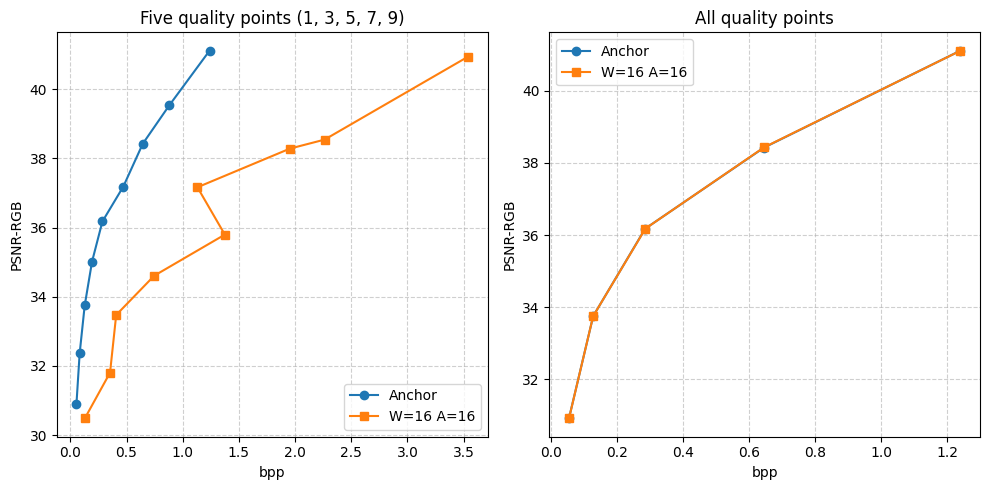

In [12]:
import matplotlib.pyplot as plt
import random

DATASET_JUSTFY = 'HEVC-B'
A_JUSTIFY = 4
W_JUSTIFY = 4

colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red',
         'tab:pink',]
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'P', 'X']
linestyles = ['-', '--', '-.', ':']


plt.figure(figsize=(10, 5))


q, bpp_anchor, psnr_anchor = averages_by_quality(df_anchor_allq, frames=32, dataset=DATASET_JUSTFY)
plt.subplot(1, 2, 1)
plt.plot(
    bpp_anchor, psnr_anchor,
    label=f'Anchor',
    marker='o',                
)

try:
    q, bpp, psnr = averages_by_quality(
        df_quant_allq,
        w=W_JUSTIFY, a=A_JUSTIFY,
        calib_res=256, calib_seq=1000, frames=32,
        dataset=DATASET_JUSTFY
    )
    
    color = random.choice(colors)
    marker = random.choice(markers)
    ls = random.choice(linestyles)
    
    bd_rate_val = bd_rate(bpp_anchor, psnr_anchor, bpp, psnr, 'akima')

       
    
    plt.plot(
        bpp, psnr,
        label=f'W={w} A={a}',
        marker='s',
        # linestyle=ls,
        # color=color
    )

    bd_rate_val = bd_rate(bpp_anchor, psnr_anchor, bpp, psnr, 'akima')
    print(f'BD-Rate (W={w}, A={a}): {bd_rate_val:.2f}%')
    
except ValueError as e:
    print (e)

plt.xlabel('bpp')
plt.ylabel('PSNR-RGB')
plt.title('Five quality points (1, 3, 5, 7, 9)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()


##########
# SECOND PART

q, bpp_anchor, psnr_anchor = averages_by_quality(df_anchor, frames=32, dataset=DATASET_JUSTFY)
plt.subplot(1, 2, 2)
plt.plot(
    bpp_anchor, psnr_anchor,
    label=f'Anchor',
    marker='o',                
)



try:
    q, bpp, psnr = averages_by_quality(
        df_quant,
        w=w, a=a,
        calib_res=256, calib_seq=1000, frames=32,
        dataset=DATASET_JUSTFY
    )
    
    color = random.choice(colors)
    marker = random.choice(markers)
    ls = random.choice(linestyles)
    
    bd_rate_val = bd_rate(bpp_anchor, psnr_anchor, bpp, psnr, 'akima')

    # if bd_rate_val > 7:
    #     continue

    print(f'BD-Rate (W={w}, A={a}): {bd_rate_val:.2f}%')
    
    plt.plot(
        bpp, psnr,
        label=f'W={w} A={a}',
        marker='s',
        # linestyle=ls,
        # color=color
    )

    bd_rate_val = bd_rate(bpp_anchor, psnr_anchor, bpp, psnr, 'akima')
    print(f'BD-Rate (W={w}, A={a}): {bd_rate_val:.2f}%')
    
except ValueError as e:
    print (e)

plt.xlabel('bpp')
plt.ylabel('PSNR-RGB')
plt.title('All quality points')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()


plt.show()

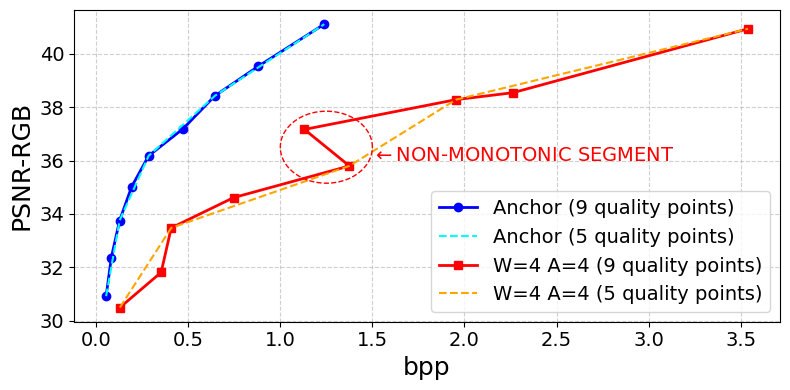

In [13]:
import matplotlib.pyplot as plt
import random

from pyparsing import line

DATASET_JUSTFY = 'HEVC-B'
A_JUSTIFY = 4
W_JUSTIFY = 4



plt.figure(figsize=(8, 4))


q, bpp_anchor, psnr_anchor = averages_by_quality(df_anchor_allq, frames=32, dataset=DATASET_JUSTFY)
plt.plot(
    bpp_anchor, psnr_anchor,
    label=f'Anchor (9 quality points)',
    marker='o',        
    color='blue',
    linewidth=2        
)

q, bpp_anchor, psnr_anchor = averages_by_quality(df_anchor, frames=32, dataset=DATASET_JUSTFY)
plt.plot(
    bpp_anchor, psnr_anchor,
    label=f'Anchor (5 quality points)',
    linestyle='--',    
    color='cyan'                        
)


##QUANTIZEDS

q, bpp, psnr = averages_by_quality(
    df_quant_allq,
    w=W_JUSTIFY, a=A_JUSTIFY,
    calib_res=256, calib_seq=1000, frames=32,
    dataset=DATASET_JUSTFY
)    

plt.plot(
    bpp, psnr,
    label=f'W={W_JUSTIFY} A={A_JUSTIFY} (9 quality points)',    
    marker='s',
    # linestyle=ls,
    color='red',
    linewidth=2
)




q, bpp, psnr = averages_by_quality(
    df_quant,
    w=W_JUSTIFY, a=A_JUSTIFY,
    calib_res=256, calib_seq=1000, frames=32,
    dataset=DATASET_JUSTFY
)

plt.plot(
    bpp, psnr,
    label=f'W={W_JUSTIFY} A={A_JUSTIFY} (5 quality points)',    
    linestyle='--',
    color='orange'    
)


theta = np.linspace(0, 2*np.pi, 500)
r = 1
x = r * np.cos(theta)*0.25 + 1.25
y = r * np.sin(theta)*1.35 + 36.5
plt.plot(x, y, color='red', linestyle='--', linewidth=1)
plt.text(1.5, 36, '$\leftarrow$NON-MONOTONIC SEGMENT', fontsize=14, color='red')  # offset (+1,+1) avoids overlap


plt.xlabel('bpp', fontsize=18)
plt.ylabel('PSNR-RGB', fontsize=18)
plt.legend(fontsize=14)   # aumenta a legenda
plt.tick_params(axis='both', labelsize=14)  # aumenta os ticks dos eixos
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.savefig("why5points.pdf", dpi=600, bbox_inches="tight")   # formato PNG


plt.show()

BD-Rate (W=16, A=16): 246.12%
BD-Rate (W=16, A=16): 5.95%
BD-Rate (W=16, A=16): 0.23%
BD-Rate (W=16, A=16): 0.15%
BD-Rate (W=16, A=16): 257.55%
BD-Rate (W=16, A=16): 5.13%
BD-Rate (W=16, A=16): 0.07%
BD-Rate (W=16, A=16): 0.09%
BD-Rate (W=16, A=16): 254.02%
BD-Rate (W=16, A=16): 5.73%
BD-Rate (W=16, A=16): 0.17%
BD-Rate (W=16, A=16): 0.13%


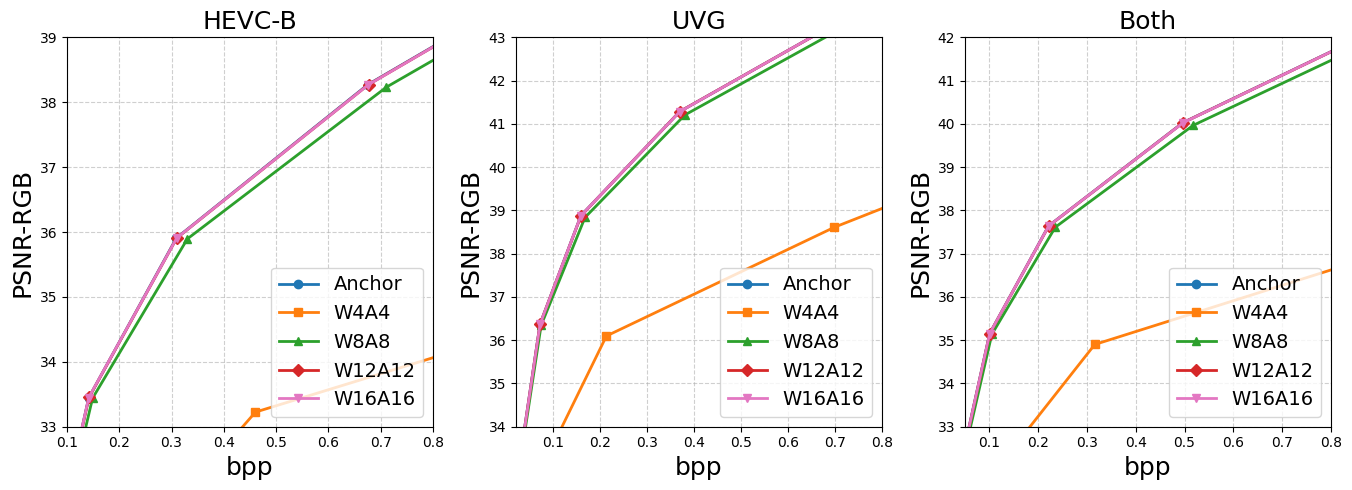

In [14]:
import matplotlib.pyplot as plt
import random

colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red',
         'tab:pink',]
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'P', 'X']
linestyles = ['-', '--', '-.', ':']
plt.figure(figsize=(18, 5))


DATASET = "HEVC-B"
q, bpp_anchor, psnr_anchor = averages_by_quality(df_anchor, frames=96, dataset=DATASET)
plt.subplot(1, 4, 1)    
plt.plot(
        bpp_anchor, psnr_anchor,
        label=f'Anchor',    
        linewidth=2,
        marker=markers[0],
        color=colors[0]            
    )    
for i,bw in enumerate([4, 8, 12, 16]):            
    q, bpp, psnr = averages_by_quality(
        df_quant,
        w=bw, a=bw,
        calib_res=256, calib_seq=1000, frames=96,
        dataset=DATASET
    ) 
    plt.plot(
        bpp, psnr,
        label=f'W{bw}A{bw}', 
        linewidth=2,
        marker=markers[i+1],
        color=colors[i+1]           
    )

    bd_rate_val = bd_rate(bpp_anchor, psnr_anchor, bpp, psnr, 'akima')
    print(f'BD-Rate (W={w}, A={a}): {bd_rate_val:.2f}%')
    plt.title(f"{DATASET}", fontsize=18)
    plt.xlabel('bpp', fontsize=18)
    plt.ylabel('PSNR-RGB', fontsize=18)        
    plt.legend(fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()  
    plt.xlim(0.1, 0.8)    # eixo X vai de 0 a 1.0
    plt.ylim(33, 39)    # eixo Y vai de 20 a 50            

DATASET = "UVG"
q, bpp_anchor, psnr_anchor = averages_by_quality(df_anchor, frames=96, dataset=DATASET)
plt.subplot(1, 4, 2)    
plt.plot(
        bpp_anchor, psnr_anchor,
        label=f'Anchor',    
        linewidth=2,
        marker=markers[0],
        color=colors[0]            
    )    
for i,bw in enumerate([4, 8, 12, 16]):            
    q, bpp, psnr = averages_by_quality(
        df_quant,
        w=bw, a=bw,
        calib_res=256, calib_seq=1000, frames=96,
        dataset=DATASET
    ) 
    plt.plot(
        bpp, psnr,
        label=f'W{bw}A{bw}', 
        linewidth=2,
        marker=markers[i+1],
        color=colors[i+1]           
    )

    bd_rate_val = bd_rate(bpp_anchor, psnr_anchor, bpp, psnr, 'akima')
    print(f'BD-Rate (W={w}, A={a}): {bd_rate_val:.2f}%')
    plt.title(f"{DATASET}", fontsize=18)
    plt.xlabel('bpp', fontsize=18)
    plt.ylabel('PSNR-RGB', fontsize=18)        
    plt.legend(fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()  
    plt.xlim(0.02, 0.8)    # eixo X vai de 0 a 1.0
    plt.ylim(34, 43)    # eixo Y vai de 20 a 50                     

DATASET = None
q, bpp_anchor, psnr_anchor = averages_by_quality(df_anchor, frames=96, dataset=DATASET)
plt.subplot(1, 4, 3)    
plt.plot(
        bpp_anchor, psnr_anchor,
        label=f'Anchor',    
        linewidth=2,
        marker=markers[0],
        color=colors[0]            
    )    
for i,bw in enumerate([4, 8, 12, 16]):            
    q, bpp, psnr = averages_by_quality(
        df_quant,
        w=bw, a=bw,
        calib_res=256, calib_seq=1000, frames=96,
        dataset=DATASET
    ) 
    plt.plot(
        bpp, psnr,
        label=f'W{bw}A{bw}', 
        linewidth=2,
        marker=markers[i+1],
        color=colors[i+1]           
    )

    bd_rate_val = bd_rate(bpp_anchor, psnr_anchor, bpp, psnr, 'akima')
    print(f'BD-Rate (W={w}, A={a}): {bd_rate_val:.2f}%')
    plt.title(f"Both", fontsize=18)
    plt.xlabel('bpp', fontsize=18)
    plt.ylabel('PSNR-RGB', fontsize=18)        
    plt.legend(fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()  
    plt.xlim(0.05, 0.8)    # eixo X vai de 0 a 1.0
    plt.ylim(33, 42)    # eixo Y vai de 20 a 50                     


plt.show()




BD-Rate (W=16, A=16): 246.12%
BD-Rate (W=16, A=16): 5.95%
BD-Rate (W=16, A=16): 0.23%
BD-Rate (W=16, A=16): 0.15%
BD-Rate (W=16, A=16): 257.55%
BD-Rate (W=16, A=16): 5.13%
BD-Rate (W=16, A=16): 0.07%
BD-Rate (W=16, A=16): 0.09%
BD-Rate (W=16, A=16): 254.02%
BD-Rate (W=16, A=16): 5.73%
BD-Rate (W=16, A=16): 0.17%
BD-Rate (W=16, A=16): 0.13%


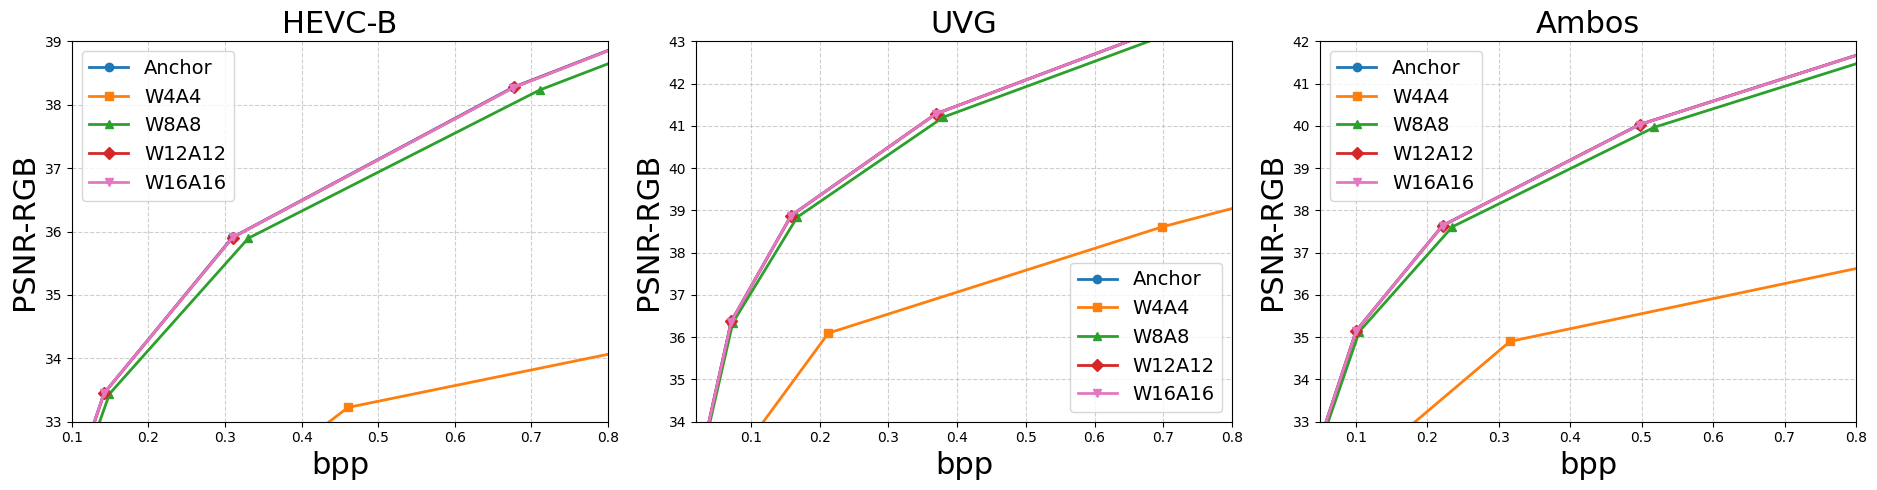

In [24]:
import matplotlib.pyplot as plt
import random

colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red',
         'tab:pink',]
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'P', 'X']
linestyles = ['-', '--', '-.', ':']
plt.figure(figsize=(25, 5))


DATASET = "HEVC-B"
q, bpp_anchor, psnr_anchor = averages_by_quality(df_anchor, frames=96, dataset=DATASET)
plt.subplot(1, 4, 1)    
plt.plot(
        bpp_anchor, psnr_anchor,
        label=f'Anchor',    
        linewidth=2,
        marker=markers[0],
        color=colors[0]            
    )    
for i,bw in enumerate([4, 8, 12, 16]):            
    q, bpp, psnr = averages_by_quality(
        df_quant,
        w=bw, a=bw,
        calib_res=256, calib_seq=1000, frames=96,
        dataset=DATASET
    ) 
    plt.plot(
        bpp, psnr,
        label=f'W{bw}A{bw}', 
        linewidth=2,
        marker=markers[i+1],
        color=colors[i+1]           
    )

    bd_rate_val = bd_rate(bpp_anchor, psnr_anchor, bpp, psnr, 'akima')
    print(f'BD-Rate (W={w}, A={a}): {bd_rate_val:.2f}%')
    plt.title(f"{DATASET}", fontsize=22)
    plt.xlabel('bpp', fontsize=22)
    plt.ylabel('PSNR-RGB', fontsize=22)        
    plt.legend(fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()  
    plt.xlim(0.1, 0.8)    # eixo X vai de 0 a 1.0
    plt.ylim(33, 39)    # eixo Y vai de 20 a 50            

DATASET = "UVG"
q, bpp_anchor, psnr_anchor = averages_by_quality(df_anchor, frames=96, dataset=DATASET)
plt.subplot(1, 4, 2)    
plt.plot(
        bpp_anchor, psnr_anchor,
        label=f'Anchor',    
        linewidth=2,
        marker=markers[0],
        color=colors[0]            
    )    
for i,bw in enumerate([4, 8, 12, 16]):            
    q, bpp, psnr = averages_by_quality(
        df_quant,
        w=bw, a=bw,
        calib_res=256, calib_seq=1000, frames=96,
        dataset=DATASET
    ) 
    plt.plot(
        bpp, psnr,
        label=f'W{bw}A{bw}', 
        linewidth=2,
        marker=markers[i+1],
        color=colors[i+1]           
    )

    bd_rate_val = bd_rate(bpp_anchor, psnr_anchor, bpp, psnr, 'akima')
    print(f'BD-Rate (W={w}, A={a}): {bd_rate_val:.2f}%')
    plt.title(f"{DATASET}", fontsize=22)
    plt.xlabel('bpp', fontsize=22)
    plt.ylabel('PSNR-RGB', fontsize=22)        
    plt.legend(fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()  
    plt.xlim(0.02, 0.8)    # eixo X vai de 0 a 1.0
    plt.ylim(34, 43)    # eixo Y vai de 20 a 50                     

DATASET = None
q, bpp_anchor, psnr_anchor = averages_by_quality(df_anchor, frames=96, dataset=DATASET)
plt.subplot(1, 4, 3)    
plt.plot(
        bpp_anchor, psnr_anchor,
        label=f'Anchor',    
        linewidth=2,
        marker=markers[0],
        color=colors[0]            
    )    
for i,bw in enumerate([4, 8, 12, 16]):            
    q, bpp, psnr = averages_by_quality(
        df_quant,
        w=bw, a=bw,
        calib_res=256, calib_seq=1000, frames=96,
        dataset=DATASET
    ) 
    plt.plot(
        bpp, psnr,
        label=f'W{bw}A{bw}', 
        linewidth=2,
        marker=markers[i+1],
        color=colors[i+1]           
    )

    bd_rate_val = bd_rate(bpp_anchor, psnr_anchor, bpp, psnr, 'akima')
    print(f'BD-Rate (W={w}, A={a}): {bd_rate_val:.2f}%')
    plt.title(f"Ambos", fontsize=22)
    plt.xlabel('bpp', fontsize=22)
    plt.ylabel('PSNR-RGB', fontsize=22)        
    plt.legend(fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()  
    plt.xlim(0.05, 0.8)    # eixo X vai de 0 a 1.0
    plt.ylim(33, 42)    # eixo Y vai de 20 a 50                     


plt.show()


